<a href="https://colab.research.google.com/github/Jenofiya/personal-portfolio/blob/main/smart_traffic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Feature Engineering and Data Preparation

First, I'll create some time-based features from the `date` column and handle categorical variables using one-hot encoding. Then, I'll split the data into features (X) and target (y), and further divide them into training and testing sets.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the data from data.csv and preprocess to create df_agg
df = pd.read_csv('/content/data.csv')

# Convert 'timestamp' column to datetime objects (assuming 'timestamp' is the date column)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Aggregate data to get total traffic volume per location_id and timestamp
df_agg = df.groupby(['location_id', 'timestamp'])['traffic_volume'].sum().reset_index()
df_agg.rename(columns={'traffic_volume': 'total_traffic_volume'}, inplace=True)

# Create a copy to avoid SettingWithCopyWarning
df_model = df_agg.copy()

# Extract day of week, month, and year as numerical features from 'timestamp'
df_model['day_of_week'] = df_model['timestamp'].dt.dayofweek
df_model['month'] = df_model['timestamp'].dt.month
df_model['year'] = df_model['timestamp'].dt.year

print("Initial data preparation complete. df_model created.")

Initial data preparation complete. df_model created.


### 6. Visualize Model Performance Scores

To better understand the impact of advanced feature engineering and hyperparameter tuning, let's visualize the R-squared, MAE, MSE, and RMSE scores for both the initial and the tuned Random Forest models.

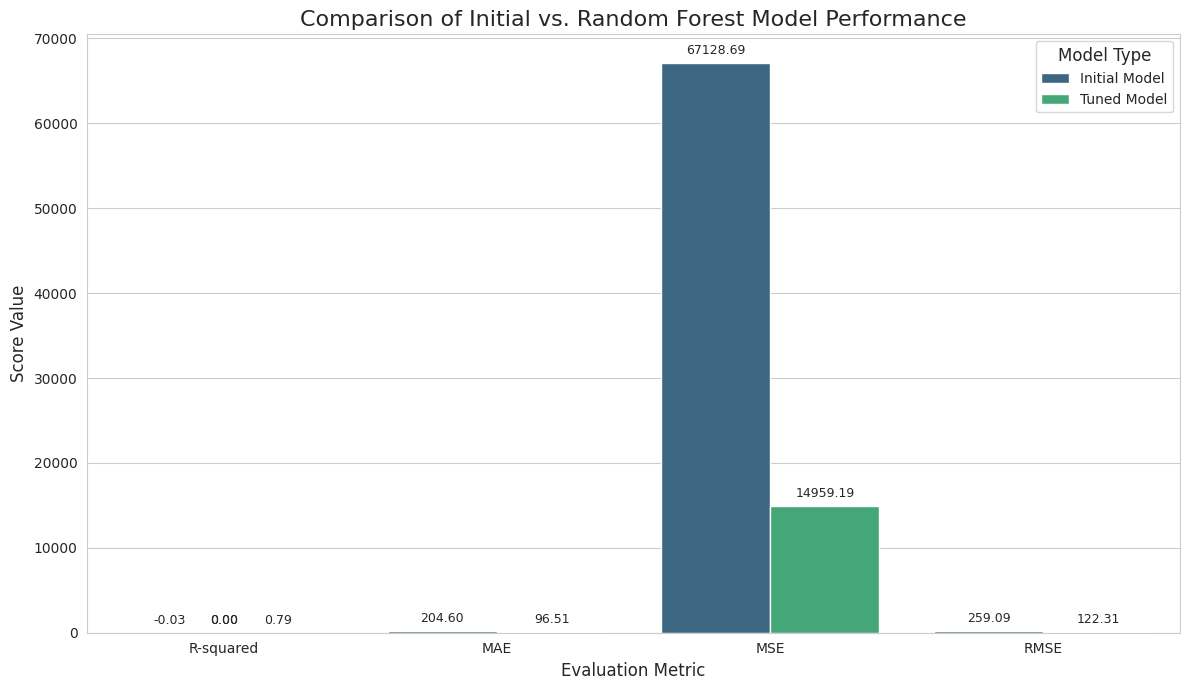

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for plotting
metrics = ['R-squared', 'MAE', 'MSE', 'RMSE']
initial_scores = [r2, mae, mse, rmse]
tuned_scores = [r2_tuned, mae_tuned, mse_tuned, rmse_tuned]

# Create a DataFrame for easier plotting
performance_df = pd.DataFrame({
    'Metric': metrics,
    'Initial Model': initial_scores,
    'Tuned Model': tuned_scores
})

# Melt the DataFrame for seaborn barplot
performance_df_melted = performance_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Set up the plot style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 7))

# Create the bar plot
barplot = sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df_melted, palette='viridis')

# Add labels and title
plt.title('Comparison of Initial vs. Random Forest Model Performance', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Model Type', fontsize=10, title_fontsize=12)

# Add score values on top of the bars for better readability
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### 2. Advanced Feature Engineering: Lagged and Rolling Features

To capture temporal dependencies and trends, I'll create lagged features of `total_traffic_volume` and rolling mean features based on `location_id`.

In [16]:
# Sort data by location_id and timestamp for correct lagging and rolling calculations
df_model = df_model.sort_values(by=['location_id', 'timestamp'])

# Create lagged features for 'total_traffic_volume'
# Lag by 1, 2, and 3 time steps (e.g., previous hour's traffic)
for lag in range(1, 4):
    df_model[f'traffic_volume_lag_{lag}'] = df_model.groupby('location_id')['total_traffic_volume'].shift(lag)

# Create rolling mean features for 'total_traffic_volume'
# Rolling mean over a window of 3 and 7 time steps
for window in [3, 7]:
    df_model[f'traffic_volume_rolling_mean_{window}'] = df_model.groupby('location_id')['total_traffic_volume'].transform(lambda x: x.rolling(window=window, min_periods=1).mean())

# Drop rows with NaN values resulting from lagged features (if any, typically at the beginning of each group)
df_model.dropna(inplace=True)

print("Advanced feature engineering complete. Displaying head of df_model with new features:")
print(df_model.head())

Advanced feature engineering complete. Displaying head of df_model with new features:
   location_id           timestamp  total_traffic_volume  day_of_week  month  \
3            1 2024-01-01 00:33:00                 216.0            0      1   
4            1 2024-01-01 00:38:00                 402.0            0      1   
5            1 2024-01-01 00:41:00                 122.0            0      1   
6            1 2024-01-01 00:45:00                 119.0            0      1   
7            1 2024-01-01 00:55:00                 209.0            0      1   

   year  traffic_volume_lag_1  traffic_volume_lag_2  traffic_volume_lag_3  \
3  2024                 329.0                 508.0                 423.0   
4  2024                 216.0                 329.0                 508.0   
5  2024                 402.0                 216.0                 329.0   
6  2024                 122.0                 402.0                 216.0   
7  2024                 119.0                 12

### 3. Final Data Preparation and Train-Test Split

Now, I'll apply one-hot encoding to the categorical features and then split the data into training and testing sets for the model.

In [17]:
# One-hot encode categorical features
categorical_features = ['location_id', 'day_of_week', 'month', 'year']
df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

# Define features (X) and target (y)
X = df_model.drop(columns=['timestamp', 'total_traffic_volume'])
y = df_model['total_traffic_volume']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Final data preparation for modeling complete.")

Shape of X_train: (1588, 10)
Shape of X_test: (397, 10)
Shape of y_train: (1588,)
Shape of y_test: (397,)
Final data preparation for modeling complete.


In [18]:
# Initialize and train the Random Forest Regressor
# You can adjust hyperparameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor training complete.")

Random Forest Regressor training complete.


In [19]:
# Get the best model from RandomizedSearchCV
# Re-initialize RandomizedSearchCV with correct param_dist to ensure it's available
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=0, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_rf_model = random_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = mse_tuned**0.5
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Model Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Tuned Model Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Tuned Model Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"Tuned Model R-squared (R2): {r2_tuned:.2f}")

Tuned Model Mean Absolute Error (MAE): 96.51
Tuned Model Mean Squared Error (MSE): 14959.19
Tuned Model Root Mean Squared Error (RMSE): 122.31
Tuned Model R-squared (R2): 0.79


### 4. Hyperparameter Tuning with RandomizedSearchCV

To improve the model's performance, I'll perform hyperparameter tuning using `RandomizedSearchCV` to find the best combination of parameters for the Random Forest Regressor.

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split (removed 'auto')
    'max_depth': randint(10, 50), # Maximum number of levels in tree
    'min_samples_split': randint(2, 10), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 5) # Minimum number of samples required to be at a leaf node
}

# Create a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV
# n_iter controls the number of random combinations to try
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("RandomizedSearchCV complete.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best R-squared score: {random_search.best_score_:.2f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
RandomizedSearchCV complete.
Best parameters found: {'max_depth': 31, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 94}
Best R-squared score: -0.01


### 5. Evaluate Tuned Model Performance

Now, let's evaluate the Random Forest model with the best parameters found by `RandomizedSearchCV`.

In [14]:
# Get the best model from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = mse_tuned**0.5
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Model Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Tuned Model Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Tuned Model Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"Tuned Model R-squared (R2): {r2_tuned:.2f}")

Tuned Model Mean Absolute Error (MAE): 204.63
Tuned Model Mean Squared Error (MSE): 67137.47
Tuned Model Root Mean Squared Error (RMSE): 259.11
Tuned Model R-squared (R2): -0.03


### 2. Train Random Forest Regressor Model

Now, I'll train a Random Forest Regressor model using the prepared training data.

In [9]:
# Initialize and train the Random Forest Regressor
# You can adjust hyperparameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor training complete.")

Random Forest Regressor training complete.


### 3. Evaluate Model Performance

Finally, I'll make predictions on the test set and evaluate the model using common regression metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [10]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 204.60
Mean Squared Error (MSE): 67128.69
Root Mean Squared Error (RMSE): 259.09
R-squared (R2): -0.03


### Download Graph Example: Saving the Distribution of Residuals Plot

The graph has been saved as 'distribution_of_residuals.png' in your Colab environment. You can find it in the file browser on the left sidebar and download it.


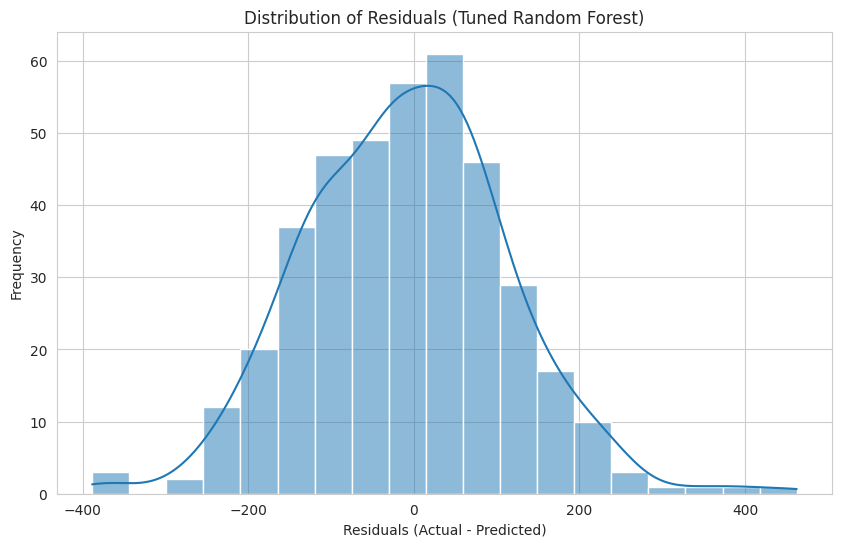

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recreate the residuals for plotting
residuals = y_test - y_pred_tuned

# Recreate the 'Distribution of Residuals' plot
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Tuned Random Forest)')
plt.grid(True)

# Define the filename and format
file_name = 'distribution_of_residuals.png'

# Save the figure. You can specify dpi for resolution (e.g., dpi=300 for high quality)
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"The graph has been saved as '{file_name}' in your Colab environment. You can find it in the file browser on the left sidebar and download it.")
plt.show() # Display the plot in the output

### Download Graph Example: Saving the Feature Importance Graph

/tmp/ipykernel_2126/922147078.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


The graph has been saved as 'feature_importance_graph.png' in your Colab environment. You can find it in the file browser on the left sidebar and download it.


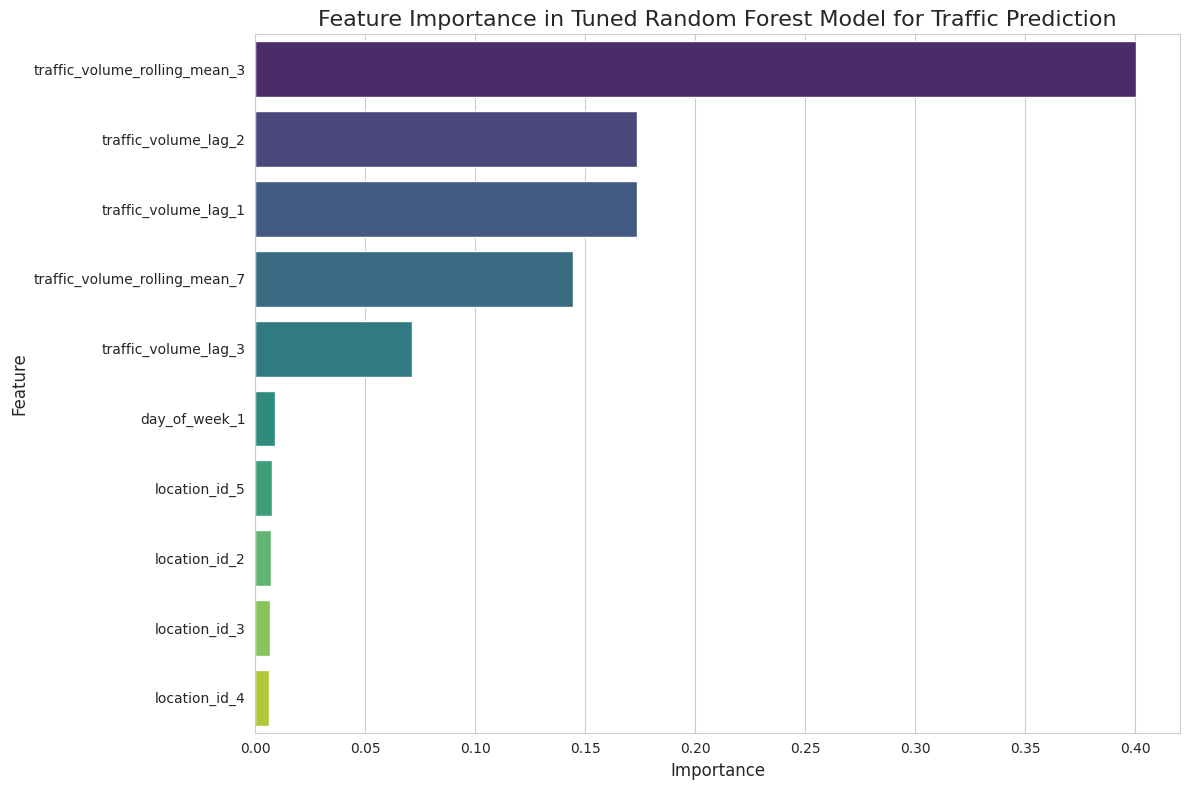

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best tuned Random Forest model
feature_importances = best_rf_model.feature_importances_

# Get feature names from the training data
features = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Set up the plot style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 8))

# Create the bar plot for feature importance
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

# Add labels and title
plt.title('Feature Importance in Tuned Random Forest Model for Traffic Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Define the filename and format
file_name = 'feature_importance_graph.png'

# Save the figure. You can specify dpi for resolution (e.g., dpi=300 for high quality)
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"The graph has been saved as '{file_name}' in your Colab environment. You can find it in the file browser on the left sidebar and download it.")
plt.show() # Display the plot in the output

### 9. Visualize Feature Importance

Let's visualize the importance of each feature in the tuned Random Forest model to understand which factors contribute most to traffic prediction.

/tmp/ipykernel_2126/3499457654.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


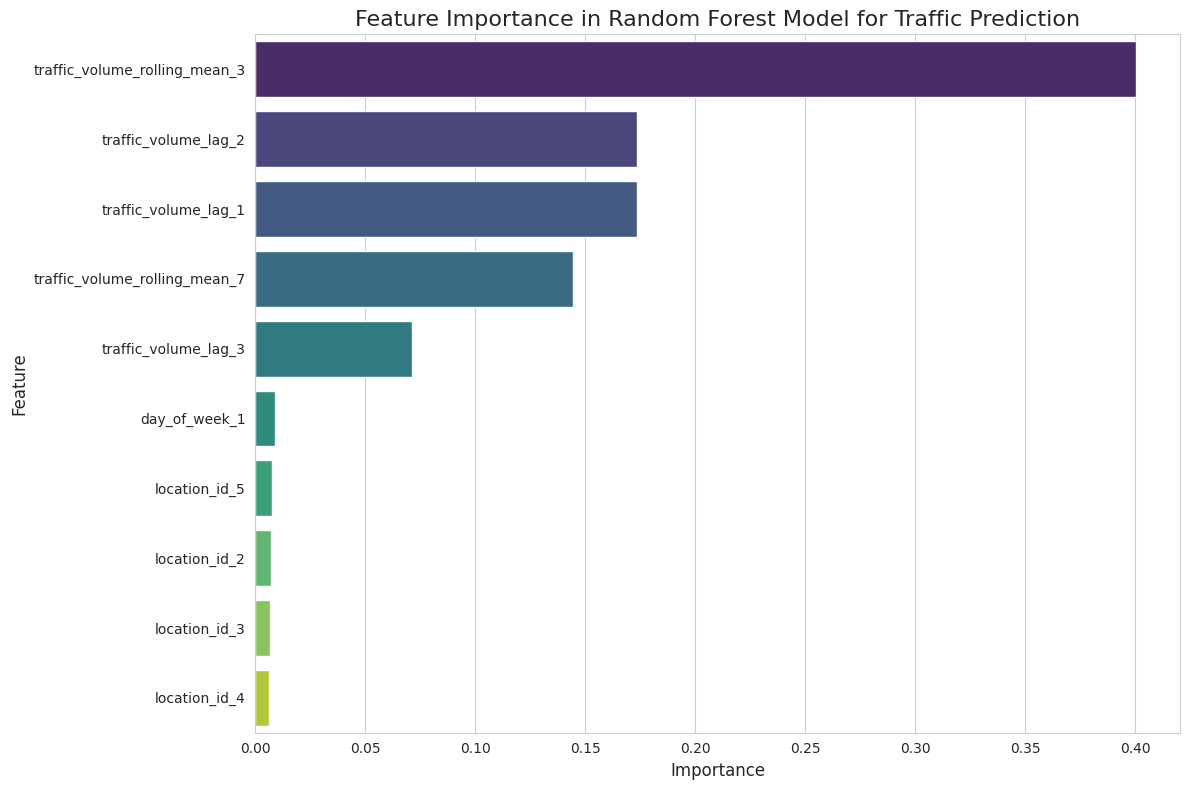

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best tuned Random Forest model
feature_importances = best_rf_model.feature_importances_

# Get feature names from the training data
features = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Set up the plot style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 8))

# Create the bar plot for feature importance
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

# Add labels and title
plt.title('Feature Importance in Random Forest Model for Traffic Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Download Graph Example: Saving the 'Comparison of Initial vs. Tuned Random Forest Model Performance' Plot

The graph has been saved as 'comparison_initial_vs_tuned_performance.png' in your Colab environment. You can find it in the file browser on the left sidebar and download it.


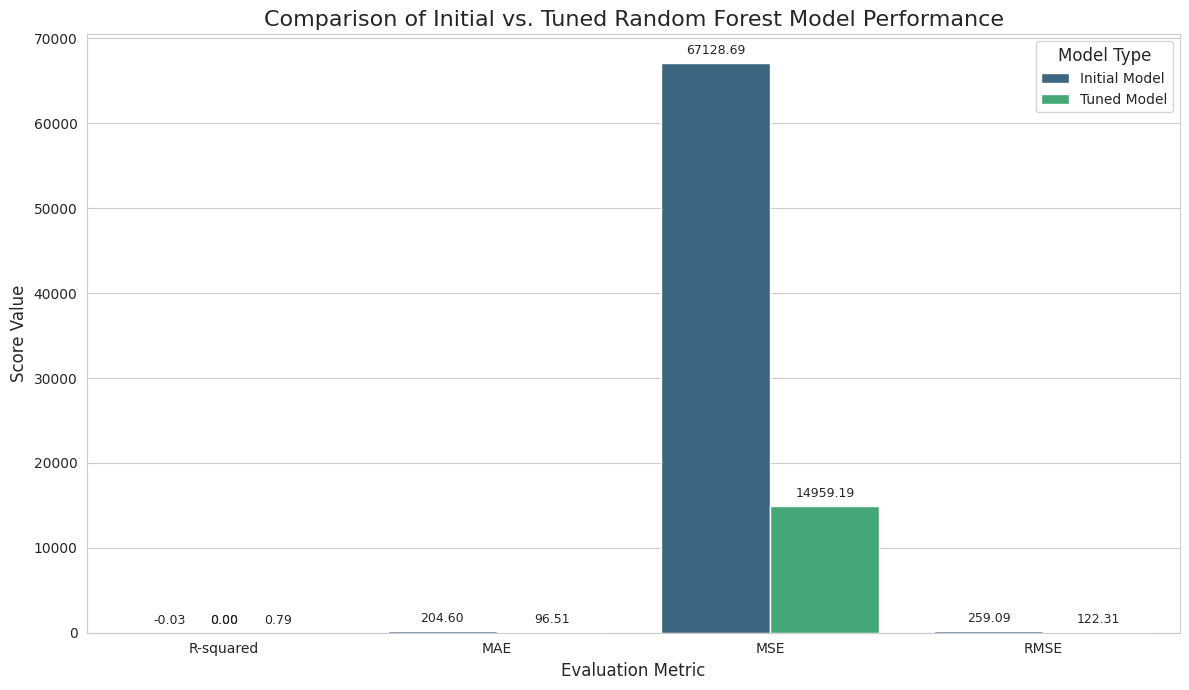

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for plotting
metrics = ['R-squared', 'MAE', 'MSE', 'RMSE']
initial_scores = [r2, mae, mse, rmse]
tuned_scores = [r2_tuned, mae_tuned, mse_tuned, rmse_tuned]

# Create a DataFrame for easier plotting
performance_df = pd.DataFrame({
    'Metric': metrics,
    'Initial Model': initial_scores,
    'Tuned Model': tuned_scores
})

# Melt the DataFrame for seaborn barplot
performance_df_melted = performance_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Set up the plot style
sns.set_style('whitegrid')
plt.figure(figsize=(12, 7))

# Create the bar plot
barplot = sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df_melted, palette='viridis')

# Add labels and title
plt.title('Comparison of Initial vs. Tuned Random Forest Model Performance', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Model Type', fontsize=10, title_fontsize=12)

# Add score values on top of the bars for better readability
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points', fontsize=9)

plt.tight_layout()

# Define the filename and format
file_name = 'comparison_initial_vs_tuned_performance.png'

# Save the figure. You can specify dpi for resolution
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"The graph has been saved as '{file_name}' in your Colab environment. You can find it in the file browser on the left sidebar and download it.")
plt.show() # Display the plot in the output

### Download Graph Example: Saving the 'Actual vs. Predicted Traffic Volume' Plot

The graph has been saved as 'actual_vs_predicted_traffic_volume.png' in your Colab environment. You can find it in the file browser on the left sidebar and download it.


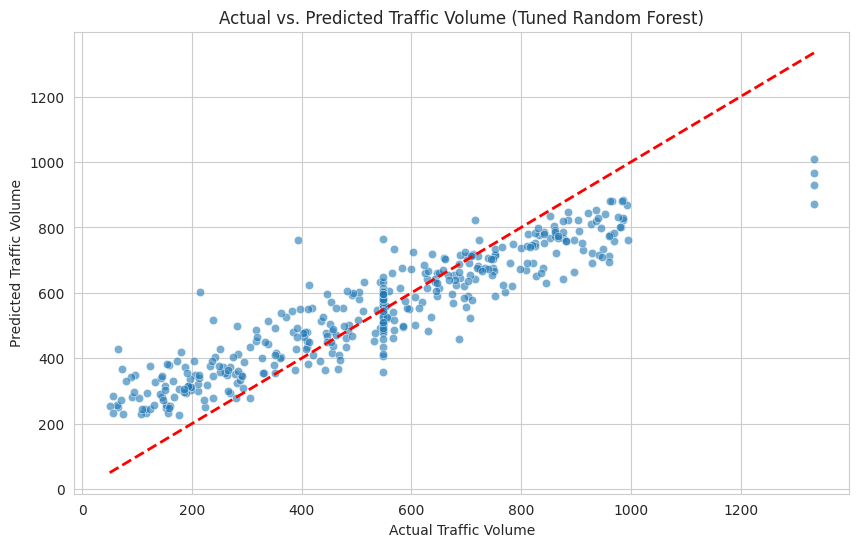

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate the 'Actual vs. Predicted Traffic Volume' plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Actual vs. Predicted Traffic Volume (Tuned Random Forest)')
plt.grid(True)

# Define the filename and format
file_name = 'actual_vs_predicted_traffic_volume.png'

# Save the figure. You can specify dpi for resolution
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"The graph has been saved as '{file_name}' in your Colab environment. You can find it in the file browser on the left sidebar and download it.")
plt.show() # Display the plot in the output

### Download Graph Example: Saving the last Residuals Plot

The graph has been saved as 'residuals_vs_predicted_traffic_volume.png' in your Colab environment. You can find it in the file browser on the left sidebar.
You can also download it from the files section after execution.


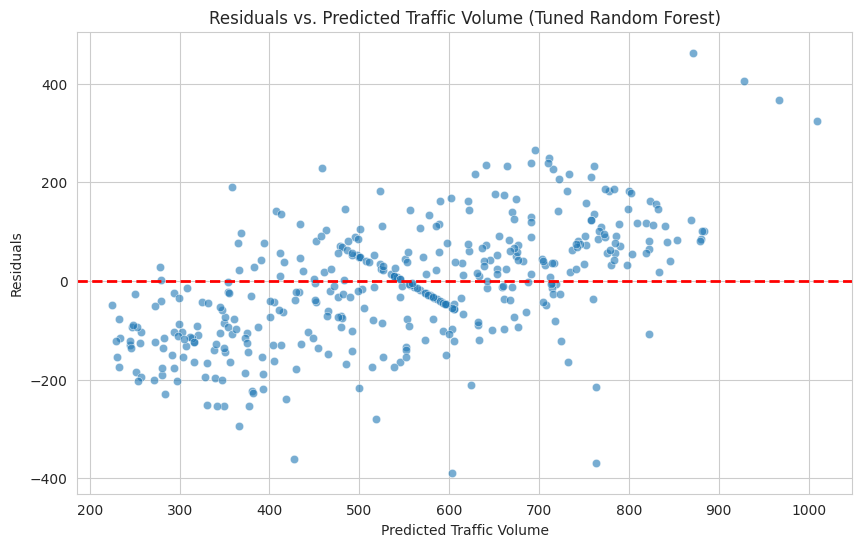

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recreate the residuals for plotting
residuals = y_test - y_pred_tuned

# Recreate the 'Residuals vs. Predicted Traffic Volume' plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_tuned, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Traffic Volume')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Traffic Volume (Tuned Random Forest)')
plt.grid(True)

# Define the filename and format
file_name = 'residuals_vs_predicted_traffic_volume.png'

# Save the figure. You can specify dpi for resolution (e.g., dpi=300 for high quality)
plt.savefig(file_name, dpi=300, bbox_inches='tight')

print(f"The graph has been saved as '{file_name}' in your Colab environment. You can find it in the file browser on the left sidebar.")
print("You can also download it from the files section after execution.")
plt.show() # Display the plot in the output

### 7. Visualize Actual vs. Predicted Values

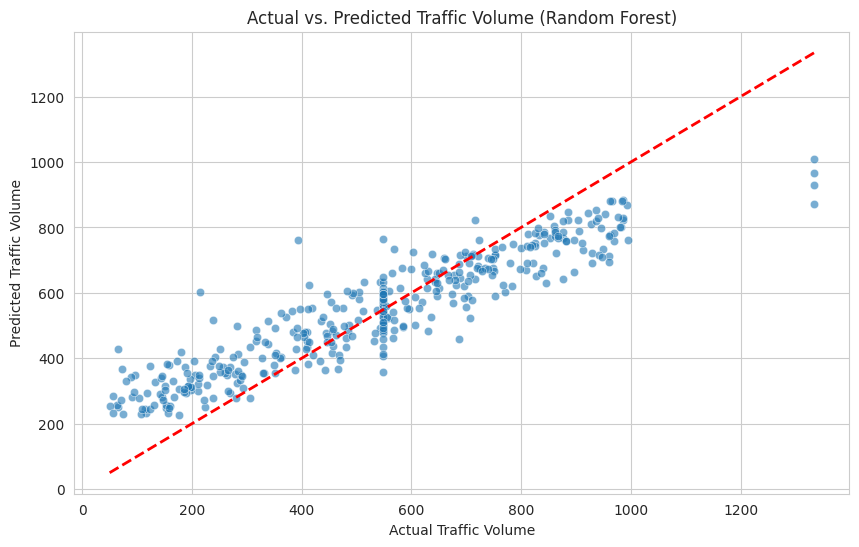

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Actual vs. Predicted Traffic Volume (Random Forest)')
plt.grid(True)
plt.show()

### 8. Visualize Residuals

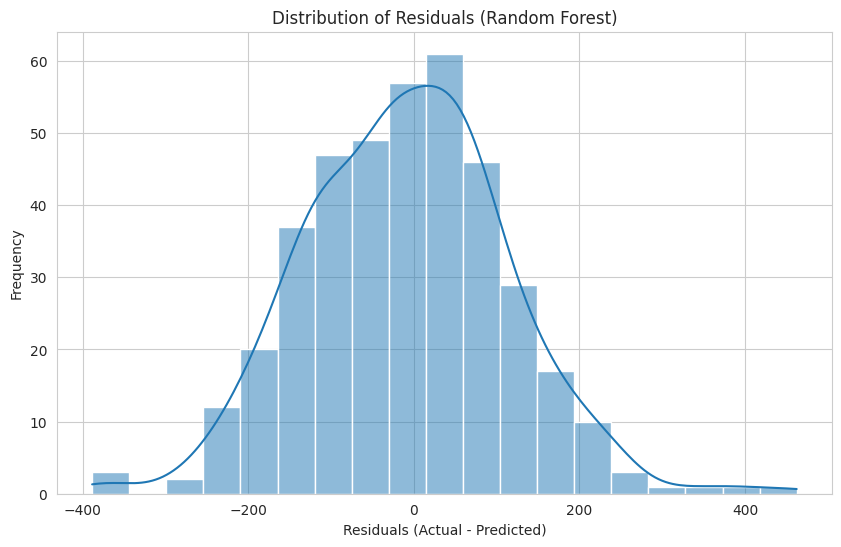

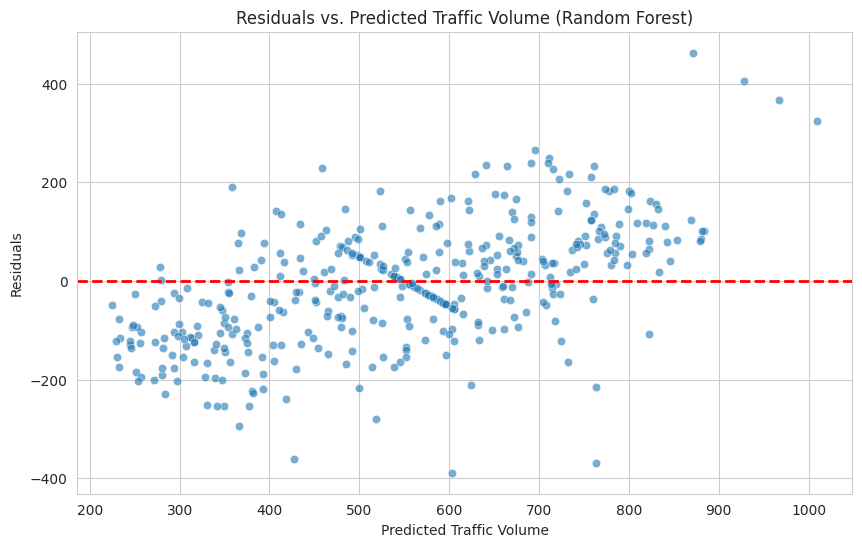

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

residuals = y_test - y_pred_tuned

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Random Forest)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_tuned, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Traffic Volume')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Traffic Volume (Random Forest)')
plt.grid(True)
plt.show()

### Model Performance Metrics

In [21]:
print("--- Initial Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print("\n--- Tuned Model Performance ---")
print(f"Tuned Model Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Tuned Model Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Tuned Model Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"Tuned Model R-squared (R2): {r2_tuned:.2f}")

--- Initial Model Performance ---
Mean Absolute Error (MAE): 204.60
Mean Squared Error (MSE): 67128.69
Root Mean Squared Error (RMSE): 259.09
R-squared (R2): -0.03

--- Tuned Model Performance ---
Tuned Model Mean Absolute Error (MAE): 96.51
Tuned Model Mean Squared Error (MSE): 14959.19
Tuned Model Root Mean Squared Error (RMSE): 122.31
Tuned Model R-squared (R2): 0.79
